In [1]:
!pip install scikit-learn gensim streamlit pandas numpy matplotlib seaborn nltk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 30.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 46.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 46.3 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_20newsgroups
from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer
from gensim.models import Word2Vec, Doc2Vec
from gensim.utils import simple_preprocess
from sklearn.base import BaseEstimator, TransformerMixin
import nltk
from nltk.corpus import stopwords

from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, accuracy_score

import re
from sklearn.feature_extraction.text import CountVectorizer
from gensim.models.doc2vec import TaggedDocument
from nltk.stem import WordNetLemmatizer

from sklearn.metrics import f1_score
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings('ignore')

import pickle

In [3]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [4]:
categories = ['sci.space', 'sci.med', 'comp.graphics', 'rec.sport.baseball']
newsgroups = fetch_20newsgroups(
    subset='all',
    categories=categories,
    remove=('headers', 'footers', 'quotes')
)

df = pd.DataFrame({
    'text': newsgroups.data,
    'target': newsgroups.target,
    'target_name': [newsgroups.target_names[i] for i in newsgroups.target]
})

X_train, X_test, y_train, y_test = train_test_split(
    df['text'], df['target'], test_size=0.2, random_state=42, stratify=df['target']
)

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text_lemmatize(text):
    """
    Токенизация, удаление стоп-слов и лемматизация.
    """
    tokens = simple_preprocess(text)
    processed_tokens = []
    for token in tokens:
        if token not in stop_words:
            lemma = lemmatizer.lemmatize(token)
            processed_tokens.append(lemma)
    return processed_tokens

train_tokens = [preprocess_text_lemmatize(t) for t in X_train]
test_tokens = [preprocess_text_lemmatize(t) for t in X_test]

tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words='english',
    ngram_range=(1, 2)
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

w2v_model = Word2Vec(
    sentences=train_tokens,
    vector_size=100,
    window=5,
    min_count=1,
    workers=4,
    epochs=10
)

def document_vector_w2v(doc, model):
    doc_vec = np.array([model.wv[word] for word in doc if word in model.wv])
    return doc_vec.mean(axis=0) if doc_vec.any() else np.zeros(model.vector_size)

X_train_w2v = np.array([document_vector_w2v(doc, w2v_model) for doc in train_tokens])
X_test_w2v = np.array([document_vector_w2v(doc, w2v_model) for doc in test_tokens])

tagged_train_docs = [TaggedDocument(words=doc, tags=[str(i)]) for i, doc in enumerate(train_tokens)]
tagged_test_docs = [TaggedDocument(words=doc, tags=[str(i)]) for i, doc in enumerate(test_tokens)]

d2v_model = Doc2Vec(
    documents=tagged_train_docs,
    vector_size=100,
    window=5,
    min_count=1,
    workers=4,
    epochs=10
)

X_train_d2v = np.array([d2v_model.infer_vector(doc.words) for doc in tagged_train_docs])
X_test_d2v = np.array([d2v_model.infer_vector(doc.words) for doc in tagged_test_docs])

print(f"TF-IDF Shape:  {X_train_tfidf.shape} {type(X_train_tfidf)}")
print(f"Word2Vec Shape:{X_train_w2v.shape} {type(X_train_w2v)}")
print(f"Doc2Vec Shape: {X_train_d2v.shape} {type(X_train_d2v)}")

TF-IDF Shape:  (3155, 5000) <class 'scipy.sparse._csr.csr_matrix'>
Word2Vec Shape:(3155, 100) <class 'numpy.ndarray'>
Doc2Vec Shape: (3155, 100) <class 'numpy.ndarray'>


SVM (TF-IDF): Accuracy=0.8758, F1=0.8751
Random Forest (TF-IDF): Accuracy=0.8124, F1=0.8117
Gradient Boosting (TF-IDF): Accuracy=0.7833, F1=0.7870
SVM (Word2Vec): Accuracy=0.8340, F1=0.8327
Random Forest (Word2Vec): Accuracy=0.8150, F1=0.8139
Gradient Boosting (Word2Vec): Accuracy=0.7985, F1=0.7979
                       Model Vectorization  Accuracy  Precision  Recall  F1-Score
                SVM (TF-IDF)        TF-IDF    0.8758     0.8784  0.8758    0.8751
              SVM (Word2Vec)      Word2Vec    0.8340     0.8387  0.8340    0.8327
    Random Forest (Word2Vec)      Word2Vec    0.8150     0.8161  0.8150    0.8139
      Random Forest (TF-IDF)        TF-IDF    0.8124     0.8147  0.8124    0.8117
Gradient Boosting (Word2Vec)      Word2Vec    0.7985     0.8012  0.7985    0.7979
  Gradient Boosting (TF-IDF)        TF-IDF    0.7833     0.8136  0.7833    0.7870


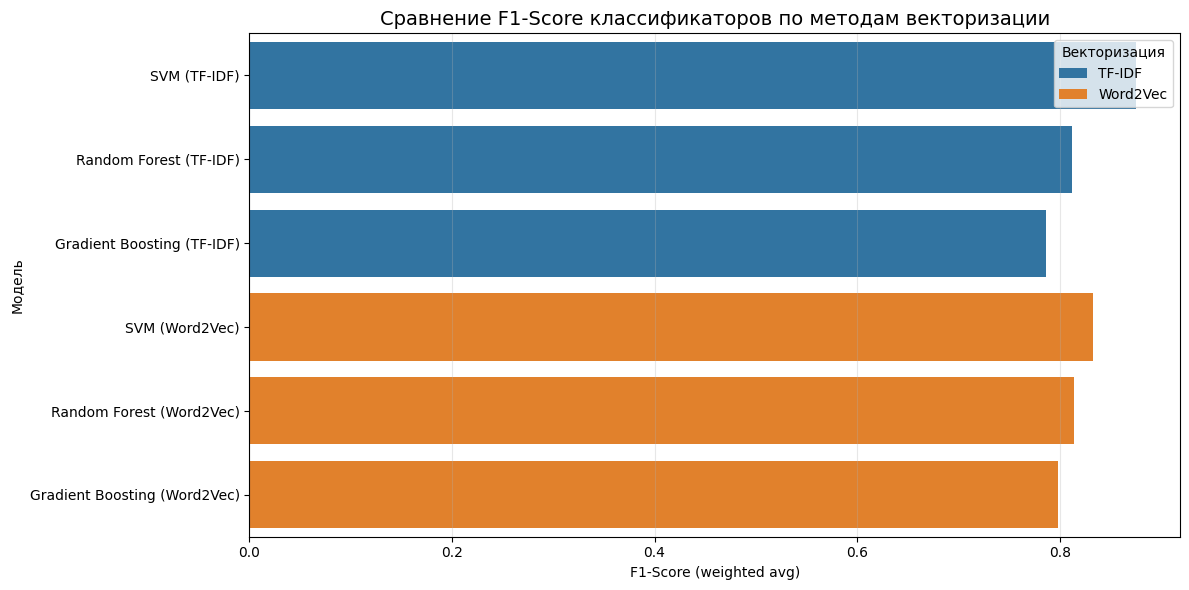

Модель: SVM (TF-IDF)
Векторизация: TF-IDF
Accuracy: 0.8758
Precision: 0.8784
Recall: 0.8758
F1-Score: 0.8751
                    precision    recall  f1-score   support

         sci.space       0.88      0.91      0.89       195
           sci.med       0.83      0.95      0.89       199
     comp.graphics       0.92      0.84      0.88       198
rec.sport.baseball       0.88      0.80      0.84       197

          accuracy                           0.88       789
         macro avg       0.88      0.88      0.88       789
      weighted avg       0.88      0.88      0.88       789



In [5]:
models_tfidf = {
    'SVM (TF-IDF)': LinearSVC(random_state=42, max_iter=1000),
    'Random Forest (TF-IDF)': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting (TF-IDF)': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

models_w2v = {
    'SVM (Word2Vec)': LinearSVC(random_state=42, max_iter=1000),
    'Random Forest (Word2Vec)': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting (Word2Vec)': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results = []

for name, model in models_tfidf.items():
    model.fit(X_train_tfidf, y_train)
    preds = model.predict(X_test_tfidf)

    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds, average='weighted')
    precision = classification_report(y_test, preds, output_dict=True)['weighted avg']['precision']
    recall = classification_report(y_test, preds, output_dict=True)['weighted avg']['recall']

    results.append({
        'Model': name,
        'Vectorization': 'TF-IDF',
        'Accuracy': acc,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    })
    print(f"{name}: Accuracy={acc:.4f}, F1={f1:.4f}")

for name, model in models_w2v.items():
    model.fit(X_train_w2v, y_train)
    preds = model.predict(X_test_w2v)

    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds, average='weighted')
    precision = classification_report(y_test, preds, output_dict=True)['weighted avg']['precision']
    recall = classification_report(y_test, preds, output_dict=True)['weighted avg']['recall']

    results.append({
        'Model': name,
        'Vectorization': 'Word2Vec',
        'Accuracy': acc,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    })
    print(f"{name}: Accuracy={acc:.4f}, F1={f1:.4f}")

results_df = pd.DataFrame(results)

pd.set_option('display.float_format', lambda x: '%.4f' % x)
print(results_df.sort_values(by='F1-Score', ascending=False).to_string(index=False))

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.barplot(data=results_df, x='F1-Score', y='Model', hue='Vectorization')
plt.title('Сравнение F1-Score классификаторов по методам векторизации', fontsize=14)
plt.xlabel('F1-Score (weighted avg)')
plt.ylabel('Модель')
plt.legend(title='Векторизация')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

best_model = results_df.loc[results_df['F1-Score'].idxmax()]
print(f"Модель: {best_model['Model']}")
print(f"Векторизация: {best_model['Vectorization']}")
print(f"Accuracy: {best_model['Accuracy']:.4f}")
print(f"Precision: {best_model['Precision']:.4f}")
print(f"Recall: {best_model['Recall']:.4f}")
print(f"F1-Score: {best_model['F1-Score']:.4f}")


if best_model['Vectorization'] == 'TF-IDF':
    best_model_name = best_model['Model']
    best_model_obj = models_tfidf[best_model_name]
    X_test_best = X_test_tfidf
else:
    best_model_name = best_model['Model']
    best_model_obj = models_w2v[best_model_name]
    X_test_best = X_test_w2v

preds_best = best_model_obj.predict(X_test_best)
print(classification_report(y_test, preds_best,
                            target_names=['sci.space', 'sci.med', 'comp.graphics', 'rec.sport.baseball']))

results_df.to_csv('classification_metrics.csv', index=False)

with open('best_model.pkl', 'wb') as f:
    pickle.dump({
        'model': best_model_obj,
        'vectorization': best_model['Vectorization'],
        'model_name': best_model['Model']
    }, f)

In [6]:
with open('best_model.pkl', 'wb') as f:
    pickle.dump({
        'model': best_model_obj,
        'vectorization': best_model['Vectorization'],
        'model_name': best_model['Model']
    }, f)

if best_model['Vectorization'] == 'TF-IDF':
    with open('vectorizer.pkl', 'wb') as f:
        pickle.dump(tfidf_vectorizer, f)

if best_model['Vectorization'] == 'Word2Vec':
    with open('w2v_model.pkl', 'wb') as f:
        pickle.dump(w2v_model, f)

if 'd2v_model' in locals():
    with open('d2v_model.pkl', 'wb') as f:
        pickle.dump(d2v_model, f)